# Bayesian modeling of Premier League standings

**Team:** [Kacper Cieśla & Tomasz Drąg]  
**Topic:** Probabilistic forecasting of **team points** in the Premier League from historical standings and process features.

---

## 1. Problem formulation

### Problem statement
English Premier League standings emerge from 380 matches per season (20 teams, double round-robin).  
We want a **probabilistic model** that predicts **points for one team** in a season (given lagged process features), including promoted/relegated clubs. A full league table can be assembled separately by ranking many such predictions (`05_backtest_models_comparison`).

### Objectives & use cases
| Use case | Question the model answers |
|----------|---------------------------|
| **Backtest** | Given history through 2024/25, how well does the model predict **each team's points** in 2025/26? |
| **Forecast** | What is the **points distribution** for each confirmed 2026/27 team? |
| **Team rating** | What is each club's latent skill on the points scale? |
| **Model choice** | Does allowing season-varying strengths (Model 2) improve fit vs. static strengths (Model 1)? |

### Data source & description
- **Source:** [datahub.io — English Premier League](https://datahub.io/football/english-premier-league), originally from [football-data.co.uk](https://www.football-data.co.uk/).
- **Files:** one CSV per season (`season-0910.csv` … `season-2526.csv`), 17 seasons, **6,460 matches**.
- **Key fields used:** `Date`, `HomeTeam`, `AwayTeam`, `FTHG`, `FTAG` (full-time goals), `FTR` (result).
- **Scope:** 42 distinct teams appear across seasons (promotion/relegation).

### Preprocessing
1. **Load & concatenate** all `season-*.csv` files; add a `season` column from the filename.
2. **Parse dates** (`Date` → datetime).
3. **Filter by train/test split** (see `02_model1_static_team`–`04_forecast_2627_comparison`): e.g. backtest trains on seasons `0910`–`2425`, tests on `2526`.
4. **Build league tables** per season (`compute_table` → `load_season_tables`).
   - Stan input: team index + **points** + process features per (season, team):
     `sot_diff_pg`, `pts_lag1`, `ppg_last10` (z-scored on training data), plus `is_promoted` (0/1).
   - Forecast: covariates from the **last training season**, then `predict_team_points()` for **one team at a time**.
     - Model 1: static `skill[team]` across seasons.
     - Model 2: `team_skill[team]` + fresh `tau_season · z` for the forecast season.
5. **Promoted teams** not in the reference season get `is_promoted=1`, covariates at training mean (z = 0), and optionally a penalty via `beta_promoted`; latent `skill = 0` if the team is new to training.
6. **Derived features for EDA:** `total_goals = FTHG + FTAG`, league tables via `compute_table`.

---

## 2. Two models (overview)

| | **Model 1 — Static team** | **Model 2 — Hierarchical team** |
|---|---------------------------|--------------------------------|
| **Input** | One team-season row: `team`, covariates | Same |
| **Idea** | Latent `skill` + covariates → predict **Pts** | `team_skill` + `season_dev` + covariates → **Pts** |
| **Output** | **Points distribution for that team** (`predict_team_points`) | Same |
| **Table (optional)** | Rank 20 separate predictions → `05_backtest_models_comparison` | Same |
| **Justification** | Simple baseline; one club in, points out | Persistent quality + fresh season shock in forecast |

Match CSVs are used only to **build tables** (`compute_table`); models do not predict individual matches.

Detailed formulas, priors, and posterior analysis are in `02_model1_static_team` (Model 1) and `03_model2_hierarchical_team` (Model 2).  
Model comparison (WAIC, PSIS-LOO, forecast) is in `04_forecast_2627_comparison`; head-to-head backtest in `05_backtest_models_comparison`.

---

## 3. Exploratory data analysis



In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# CSV files live in Project/Data/datahub.io/ 
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If the kernel cwd is /workspace, step into Project/
if not (PROJECT_ROOT / "Data" / "datahub.io").is_dir():
    PROJECT_ROOT = PROJECT_ROOT / "Project"

DATA_PATH = PROJECT_ROOT / "Data" / "datahub.io"
if not DATA_PATH.is_dir():
    raise FileNotFoundError(
        f"Expected data at {DATA_PATH}. "
        f"cwd={Path.cwd()}. Check folder name: Data (not data)."
    )

print("DATA_PATH:", DATA_PATH.resolve())


DATA_PATH: /workspace/Project/DA_Project/Data/datahub.io


In [27]:
# load data
season_dfs = []
for file in sorted(DATA_PATH.glob("season-*.csv")):
    season_id = file.stem.replace("season-", "")
    df = pd.read_csv(file)
    df["season"] = season_id
    season_dfs.append(df)

matches = pd.concat(season_dfs, ignore_index=True)
print(f"Loaded {len(season_dfs)} seasons, {len(matches)} matches")
matches.head()



Loaded 17 seasons, 6460 matches


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,season
0,2009-08-15,Aston Villa,Wigan,0,2,A,0,1,A,M Clattenburg,...,7,15,14,4,6,2,2,0,0,0910
1,2009-08-15,Blackburn,Man City,0,2,A,0,1,A,M Dean,...,5,12,9,5,4,2,1,0,0,0910
2,2009-08-15,Bolton,Sunderland,0,1,A,0,1,A,A Marriner,...,13,16,10,4,7,2,1,0,0,0910
3,2009-08-15,Chelsea,Hull,2,1,H,1,1,D,A Wiley,...,3,13,15,12,4,1,2,0,0,0910
4,2009-08-15,Everton,Arsenal,1,6,A,0,3,A,M Halsey,...,9,11,13,4,9,0,0,0,0,0910


In [28]:
matches["Date"] = pd.to_datetime(matches["Date"])
matches["total_goals"] = matches["FTHG"] + matches["FTAG"]

print("Seaons:", matches["season"].nunique())
print("Teams:", len(set(matches["HomeTeam"]) | set(matches["AwayTeam"])))
matches.info()

Seaons: 17
Teams: 42
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         6460 non-null   datetime64[ns]
 1   HomeTeam     6460 non-null   object        
 2   AwayTeam     6460 non-null   object        
 3   FTHG         6460 non-null   int64         
 4   FTAG         6460 non-null   int64         
 5   FTR          6460 non-null   object        
 6   HTHG         6460 non-null   int64         
 7   HTAG         6460 non-null   int64         
 8   HTR          6460 non-null   object        
 9   Referee      6460 non-null   object        
 10  HS           6460 non-null   int64         
 11  AS           6460 non-null   int64         
 12  HST          6460 non-null   int64         
 13  AST          6460 non-null   int64         
 14  HF           6460 non-null   int64         
 15  AF           6460 non-null   int64

In [29]:
from helping_functions import compute_table

tables = {}
for season in matches["season"].unique():
    tables[season] = compute_table(matches, season)

print(f"2025/2026 season table:\n {tables['2526']}")

2025/2026 season table:
               team  Pts  GD  GF  GA   W   D   L  position
0          Arsenal   85  44  71  27  26   7   5         1
1         Man City   78  42  77  35  23   9   6         2
2       Man United   71  19  69  50  20  11   7         3
3      Aston Villa   65   7  56  49  19   8  11         4
4        Liverpool   60  10  63  53  17   9  12         5
5      Bournemouth   57   4  58  54  13  18   7         6
6       Sunderland   54  -6  42  48  14  12  12         7
7         Brighton   53   6  52  46  14  11  13         8
8        Brentford   53   3  55  52  14  11  13         9
9          Chelsea   52   6  58  52  14  10  14        10
10          Fulham   52  -4  47  51  15   7  16        11
11       Newcastle   49  -2  53  55  14   7  17        12
12         Everton   49  -3  47  50  13  10  15        13
13           Leeds   47  -7  49  56  11  14  13        14
14  Crystal Palace   45 -10  41  51  11  12  15        15
15   Nott'm Forest   44  -3  48  51  11  11  16

Average goals per match: 2.8
FTR distribution:
 FTR
H    0.451
A    0.306
D    0.243
Name: proportion, dtype: float64


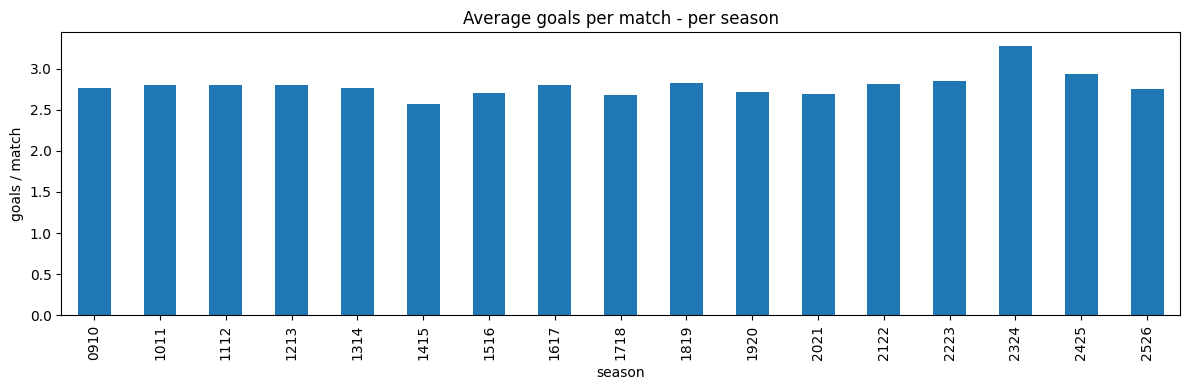

In [30]:
print("Average goals per match:", matches["total_goals"].mean().round(2))
print("FTR distribution:\n", matches["FTR"].value_counts(normalize=True).round(3)) # FTR means Full Time Result

# goals per season
goals_by_season = matches.groupby("season")["total_goals"].mean()
goals_by_season.plot(kind="bar", figsize=(12, 4), title="Average goals per match - per season")
plt.ylabel("goals / match")
plt.tight_layout()
plt.show()
# FTR meanings:
# H - Home team wins
# A - Away team wins
# D - Draw

In [31]:
from helping_functions import teams_in_season

for prev, nxt in [("2425", "2526")]:
    t_prev, t_next = teams_in_season(matches, prev), teams_in_season(matches, nxt)
    print(f"\n{prev} → {nxt}")
    print("Promoted:", sorted(t_next - t_prev))
    print("Relegated:", sorted(t_prev - t_next))


2425 → 2526
Promoted: ['Burnley', 'Leeds', 'Sunderland']
Relegated: ['Ipswich', 'Leicester', 'Southampton']


In [32]:
PL_2627 = sorted(
    (teams_in_season(matches, "2526") - {"Burnley", "West Ham", "Wolves"})
    | {"Coventry", "Ipswich", "Hull City"}
)
print(f"PL 2026/27: {len(PL_2627)} teams")
for i, t in enumerate(PL_2627, 1):
    print(f"{i:2d}. {t}")

PL 2026/27: 20 teams
 1. Arsenal
 2. Aston Villa
 3. Bournemouth
 4. Brentford
 5. Brighton
 6. Chelsea
 7. Coventry
 8. Crystal Palace
 9. Everton
10. Fulham
11. Hull City
12. Ipswich
13. Leeds
14. Liverpool
15. Man City
16. Man United
17. Newcastle
18. Nott'm Forest
19. Sunderland
20. Tottenham
